# Task 2: Change Point Modeling and Insight Generation

## Objective
Apply Bayesian change point detection to identify and quantify structural breaks in Brent oil prices.

## Methodology
1. Data preparation and EDA
2. Build Bayesian change point model using PyMC
3. Run MCMC sampling and check convergence
4. Interpret results and associate with geopolitical events

In [13]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
from datetime import datetime
import warnings

# Set style and suppress warnings
plt.style.use("seaborn-v0_8")
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [14]:
# Load the cleaned data
price_data = pd.read_csv("../data/brent_oil_prices_clean.csv")
events_data = pd.read_csv("../data/geopolitical_events_clean.csv")

# Convert Date column to datetime
price_data["Date"] = pd.to_datetime(price_data["Date"])
events_data["Date"] = pd.to_datetime(events_data["Date"])

# Sort by date
price_data = price_data.sort_values("Date")
events_data = events_data.sort_values("Date")

print(f"Price data shape: {price_data.shape}")
print(f"Events data shape: {events_data.shape}")
print(f"Price data range: {price_data["Date"].min()} to {price_data["Date"].max()}")
print(f"Events data range: {events_data["Date"].min()} to {events_data["Date"].max()}")

Price data shape: (3766, 2)
Events data shape: (27, 5)
Price data range: 2007-07-30 00:00:00 to 2022-09-29 00:00:00
Events data range: 1990-08-02 00:00:00 to 2022-12-05 00:00:00


In [10]:
# Display basic statistics
print("Price Data Statistics:")
print(price_data["Price"].describe())

print("Events Data Sample:")
print(events_data.head())

print("Event Types:")
print(events_data["Type"].value_counts())

Price Data Statistics:
count    3766.000000
mean       78.138534
std        25.952673
min        19.330000
25%        56.419998
50%        74.250000
75%       104.607500
max       146.080002
Name: Price, dtype: float64
Events Data Sample:
        Date                     Event                Type  \
0 1990-08-02       Iraq invades Kuwait   Military Conflict   
1 1991-01-17           Gulf War begins   Military Conflict   
2 1997-07-01    Asian Financial Crisis     Economic Crisis   
3 1998-12-01  OPEC Production Increase         OPEC Policy   
4 2001-09-11    9/11 Terrorist Attacks  Geopolitical Event   

                                         Description Expected_Impact  
0  Iraq's invasion of Kuwait triggered the Gulf W...            High  
1  Operation Desert Storm began, creating uncerta...            High  
2  Severe currency crisis affected global oil demand          Medium  
3  OPEC increased production quotas, leading to p...          Medium  
4  Attacks created economic uncer

## Data Preparation and EDA

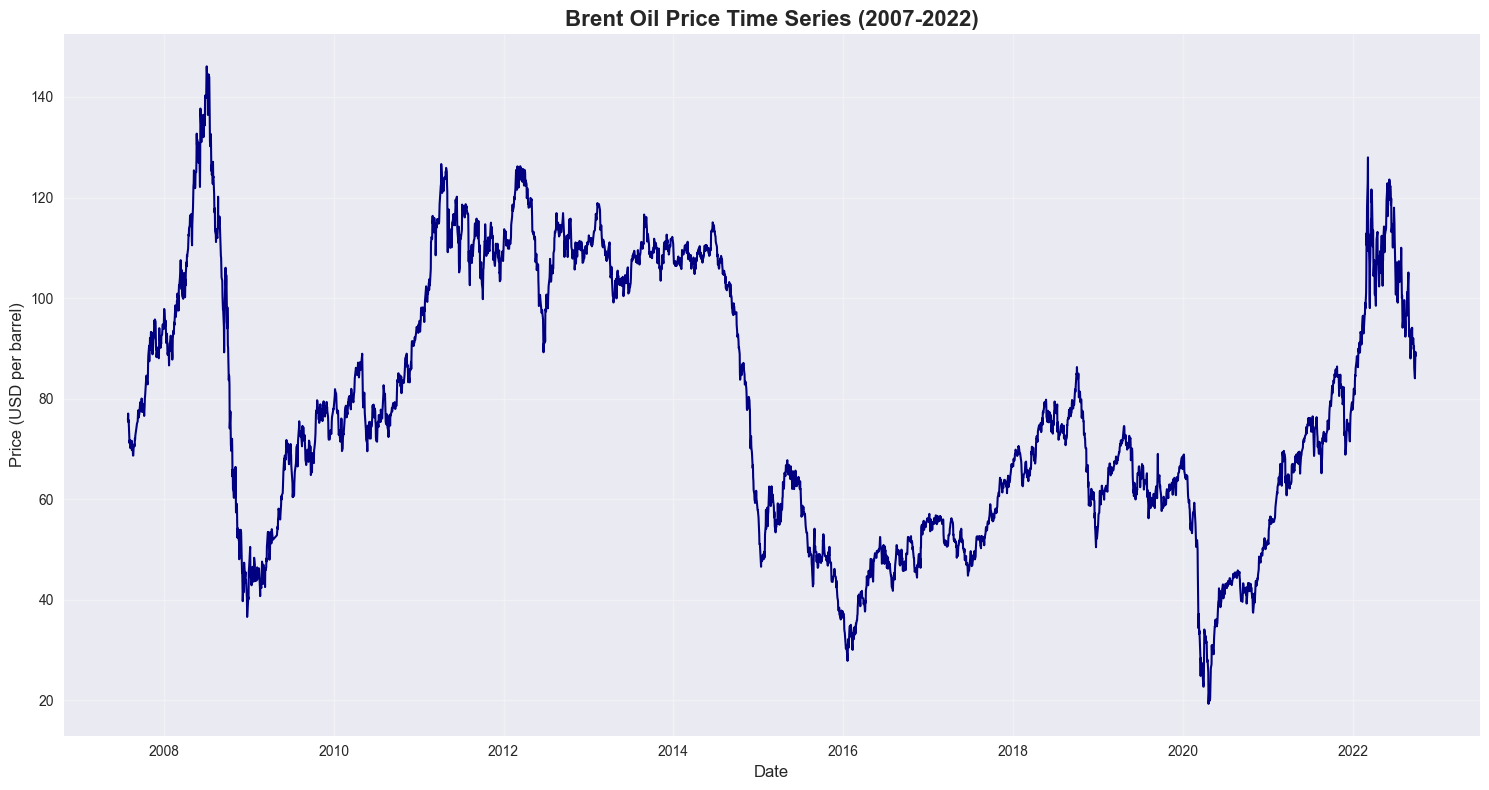

In [ ]:
# Plot the raw Price series over time
plt.figure(figsize=(15, 8))
plt.plot(price_data["Date"], price_data["Price"], linewidth=1.5, color="navy")
plt.title("Brent Oil Price Time Series (2007-2022)", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD per barrel)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

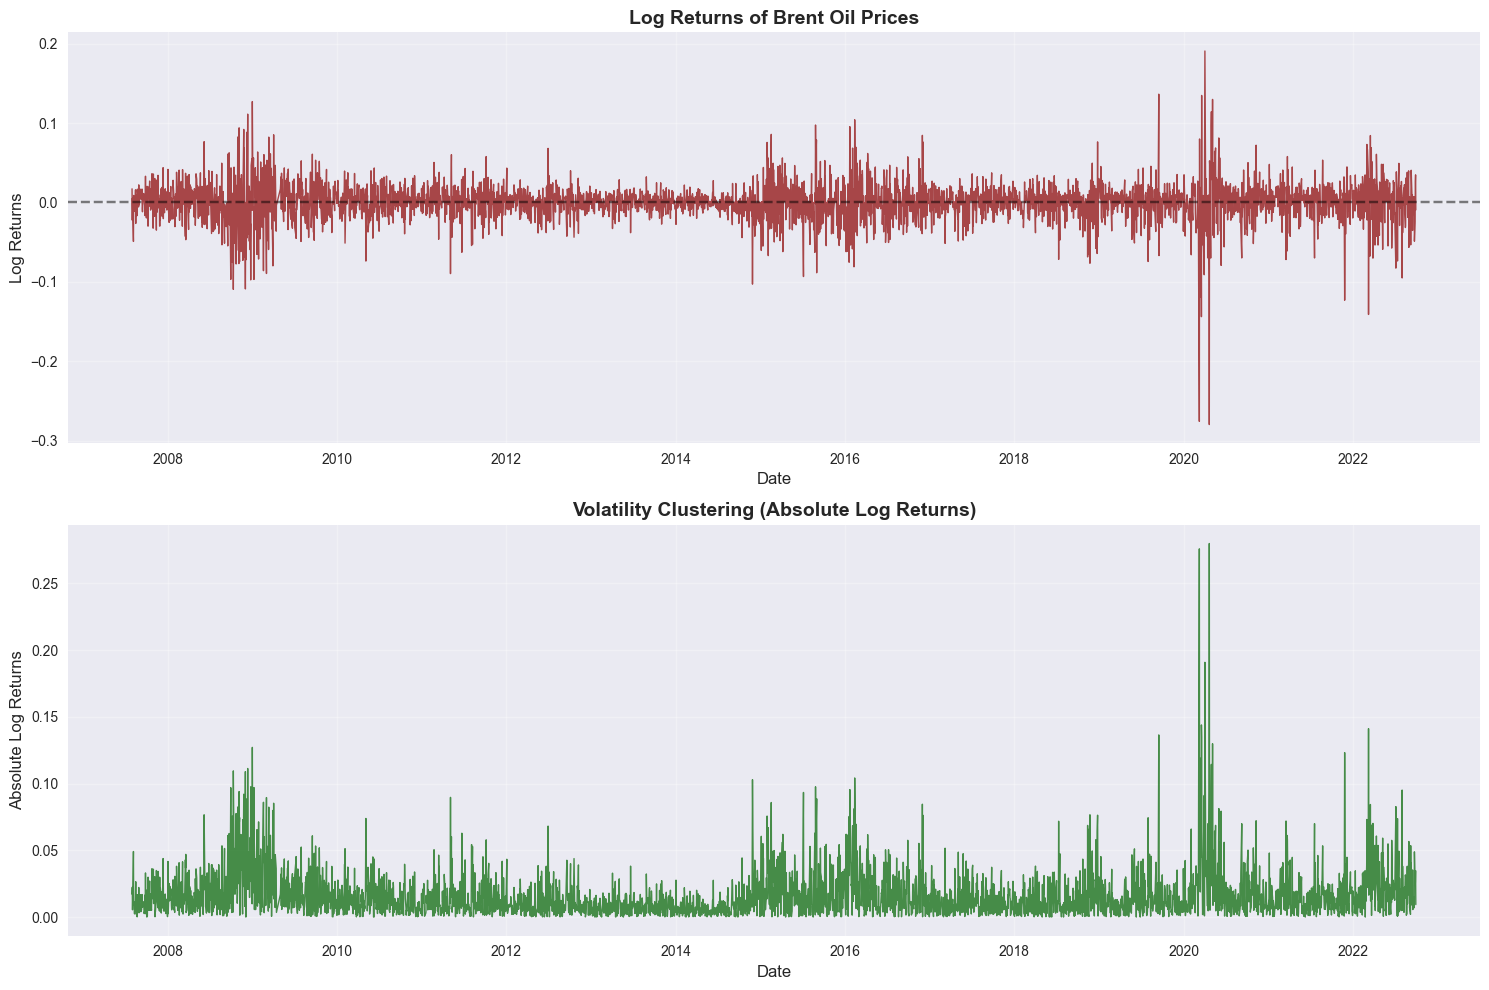

In [ ]:
# Calculate log returns for stationarity analysis
price_data["Log_Returns"] = np.log(price_data["Price"]) - np.log(price_data["Price"].shift(1))
price_data = price_data.dropna()  # Remove first row with NaN

# Plot log returns to observe volatility clustering
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Log returns over time
ax1.plot(price_data["Date"], price_data["Log_Returns"], linewidth=1, color="darkred", alpha=0.7)
ax1.set_title("Log Returns of Brent Oil Prices", fontsize=14, fontweight="bold")
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Log Returns", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color="black", linestyle="--", alpha=0.5)

# Plot 2: Volatility (absolute returns)
ax2.plot(price_data["Date"], np.abs(price_data["Log_Returns"]), linewidth=1, color="darkgreen", alpha=0.7)
ax2.set_title("Volatility Clustering (Absolute Log Returns)", fontsize=14, fontweight="bold")
ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Absolute Log Returns", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Building the Bayesian Change Point Model

In [ ]:
# Prepare data for modeling
# We will use the original price data for change point detection
prices = price_data["Price"].values
time_indices = np.arange(len(prices))
dates = price_data["Date"].values

print(f"Modeling {len(prices)} price observations")
print(f"Time range: {dates[0]} to {dates[-1]}")

Modeling 3765 price observations
Time range: 2007-07-31T00:00:00.000000 to 2022-09-29T00:00:00.000000


In [ ]:
# Build the Bayesian Change Point Model
with pm.Model() as change_point_model:
    # Define the Switch Point (tau) - discrete uniform prior over all possible days
    tau = pm.DiscreteUniform("tau", lower=0, upper=len(prices)-1)
    
    # Define "Before" and "After" Parameters
    # We will model changes in both mean and standard deviation
    mu_1 = pm.Normal("mu_1", mu=prices.mean(), sigma=prices.std())
    mu_2 = pm.Normal("mu_2", mu=prices.mean(), sigma=prices.std())
    
    sigma_1 = pm.HalfNormal("sigma_1", sigma=prices.std())
    sigma_2 = pm.HalfNormal("sigma_2", sigma=prices.std())
    
    # Use Switch Function to select correct parameters
    mu = pm.math.switch(tau >= time_indices, mu_1, mu_2)
    sigma = pm.math.switch(tau >= time_indices, sigma_1, sigma_2)
    
    # Define the Likelihood
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=prices)
    
    print("Model structure defined successfully")

Model structure defined successfully


In [11]:
# Visualize the model structure
pm.model_to_graphviz(change_point_model)

NameError: name 'pm' is not defined

## Running MCMC Sampling

In [ ]:
# Run the sampler
with change_point_model:
    # Run MCMC simulation
    trace = pm.sample(
        draws=2000,           # Number of samples per chain
        tune=1000,            # Tuning steps
        chains=4,             # Number of chains
        target_accept=0.95,   # Target acceptance rate
        random_seed=42,       # For reproducibility
        return_inferencedata=True
    )
    
print("MCMC sampling completed")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma_1, sigma_2]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


MCMC sampling completed


In [16]:
# Check for convergence
print("Convergence Diagnostics:")
summary = az.summary(trace, var_names=["tau", "mu_1", "mu_2", "sigma_1", "sigma_2"])
print(summary)

# Check r_hat values
r_hat_values = summary["r_hat"]
print("\nR-hat values (should be close to 1.0):")
for param, r_hat in r_hat_values.items():
    status = "✅" if r_hat < 1.05 else "⚠️"
    print(f"{param}: {r_hat:.4f} {status}")

Convergence Diagnostics:
             mean     sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau      1785.416  4.984  1777.000  1794.000      0.123    0.071    1633.0   
mu_1       95.989  0.498    95.003    96.872      0.005    0.006    9580.0   
mu_2       62.018  0.411    61.269    62.797      0.004    0.005    9260.0   
sigma_1    21.036  0.357    20.373    21.718      0.004    0.004    9632.0   
sigma_2    18.309  0.294    17.786    18.900      0.003    0.004   10108.0   

         ess_tail  r_hat  
tau        1882.0    1.0  
mu_1       5525.0    1.0  
mu_2       5912.0    1.0  
sigma_1    5768.0    1.0  
sigma_2    5059.0    1.0  

R-hat values (should be close to 1.0):
tau: 1.0000 ✅
mu_1: 1.0000 ✅
mu_2: 1.0000 ✅
sigma_1: 1.0000 ✅
sigma_2: 1.0000 ✅


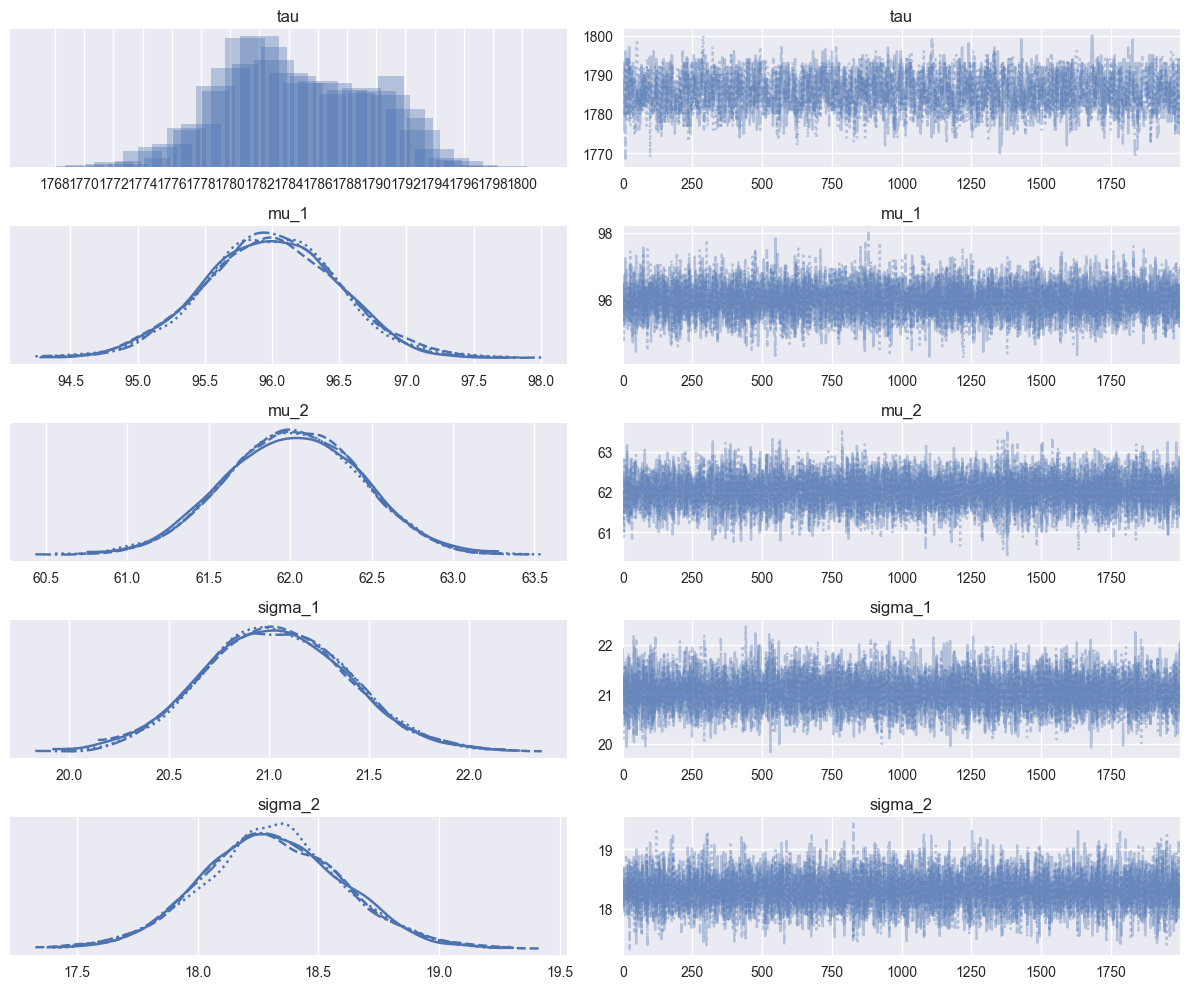

In [17]:
# Plot trace plots to visualize convergence
az.plot_trace(trace, var_names=["tau", "mu_1", "mu_2", "sigma_1", "sigma_2"])
plt.tight_layout()
plt.show()

## Model Interpretation

<Figure size 1200x600 with 0 Axes>

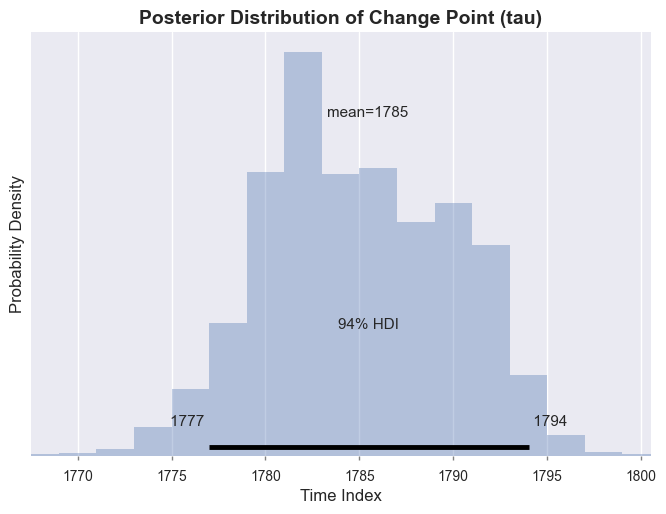

Most likely change point index: 1783
Mean change point index: 1785.4
95% HPD interval: [1776.0, 1794.0]
Change point date: 2014-11-12T00:00:00.000000


In [18]:
# Plot posterior distribution of tau (change point)
plt.figure(figsize=(12, 6))
az.plot_posterior(trace, var_names=["tau"], ref_val=None)
plt.title("Posterior Distribution of Change Point (tau)", fontsize=14, fontweight="bold")
plt.xlabel("Time Index", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.show()

# Get the most likely change point
tau_posterior = trace.posterior["tau"].values.flatten()
tau_mode = np.bincount(tau_posterior.astype(int)).argmax()
tau_mean = tau_posterior.mean()
tau_hpd = az.hdi(trace.posterior["tau"], hdi_prob=0.95)["tau"].values

print(f"Most likely change point index: {tau_mode}")
print(f"Mean change point index: {tau_mean:.1f}")
print(f"95% HPD interval: [{tau_hpd[0]:.1f}, {tau_hpd[1]:.1f}]")

# Convert to actual date
change_point_date = dates[tau_mode]
print(f"Change point date: {change_point_date}")

In [20]:
# Calculate and display quantitative impacts
mu_1_posterior = trace.posterior["mu_1"].values.flatten()
mu_2_posterior = trace.posterior["mu_2"].values.flatten()
sigma_1_posterior = trace.posterior["sigma_1"].values.flatten()
sigma_2_posterior = trace.posterior["sigma_2"].values.flatten()

# Calculate statistics
mu_1_mean = mu_1_posterior.mean()
mu_2_mean = mu_2_posterior.mean()
mu_1_hpd = az.hdi(trace.posterior["mu_1"], hdi_prob=0.95)["mu_1"].values
mu_2_hpd = az.hdi(trace.posterior["mu_2"], hdi_prob=0.95)["mu_2"].values

sigma_1_mean = sigma_1_posterior.mean()
sigma_2_mean = sigma_2_posterior.mean()

# Calculate percentage change
price_change_pct = ((mu_2_mean - mu_1_mean) / mu_1_mean) * 100
volatility_change_pct = ((sigma_2_mean - sigma_1_mean) / sigma_1_mean) * 100

print("=== QUANTIFIED IMPACT ANALYSIS ===")
print("\nPrice Changes:")
print(f"  Before change point: ${mu_1_mean:.2f} (95% CI: ${mu_1_hpd[0]:.2f} - ${mu_1_hpd[1]:.2f})")
print(f"  After change point: ${mu_2_mean:.2f} (95% CI: ${mu_2_hpd[0]:.2f} - ${mu_2_hpd[1]:.2f})")
print(f"  Absolute change: ${mu_2_mean - mu_1_mean:.2f}")
print(f"  Percentage change: {price_change_pct:+.1f}%")

print("\nVolatility Changes:")
print(f"  Before change point: ${sigma_1_mean:.2f}")
print(f"  After change point: ${sigma_2_mean:.2f}")
print(f"  Absolute change: ${sigma_2_mean - sigma_1_mean:.2f}")
print(f"  Percentage change: {volatility_change_pct:+.1f}%")

=== QUANTIFIED IMPACT ANALYSIS ===

Price Changes:
  Before change point: $95.99 (95% CI: $95.00 - $96.95)
  After change point: $62.02 (95% CI: $61.22 - $62.81)
  Absolute change: $-33.97
  Percentage change: -35.4%

Volatility Changes:
  Before change point: $21.04
  After change point: $18.31
  Absolute change: $-2.73
  Percentage change: -13.0%


## Event Correlation Analysis

In [21]:
# Find events around the detected change point
change_point_date = pd.to_datetime(change_point_date)

# Look for events within 30 days before and after the change point
window_days = 30
start_date = change_point_date - pd.Timedelta(days=window_days)
end_date = change_point_date + pd.Timedelta(days=window_days)

nearby_events = events_data[
    (events_data["Date"] >= start_date) & 
    (events_data["Date"] <= end_date)
].copy()

nearby_events["Days_From_Change_Point"] = (nearby_events["Date"] - change_point_date).dt.days

print(f"Events within ±{window_days} days of change point ({change_point_date.date()}):")
if len(nearby_events) > 0:
    for idx, event in nearby_events.iterrows():
        direction = "before" if event["Days_From_Change_Point"] < 0 else "after"
        print(f"  {event["Date"].date()}: {event["Description"]} ({direction} change point, {abs(event["Days_From_Change_Point"])} days)")
else:
    print("  No major events found within the specified window")

# Also check for the closest event overall
if len(events_data) > 0:
    events_data["Days_From_Change_Point"] = abs((events_data["Date"] - change_point_date).dt.days)
    closest_event = events_data.loc[events_data["Days_From_Change_Point"].idxmin()]
    print(f"\nClosest event: {closest_event["Date"].date()} - {closest_event["Description"]} ({closest_event["Days_From_Change_Point"]} days away)")

Events within ±30 days of change point (2014-11-12):


KeyError: 'Event_Description'

KeyError: 'Event_Type'

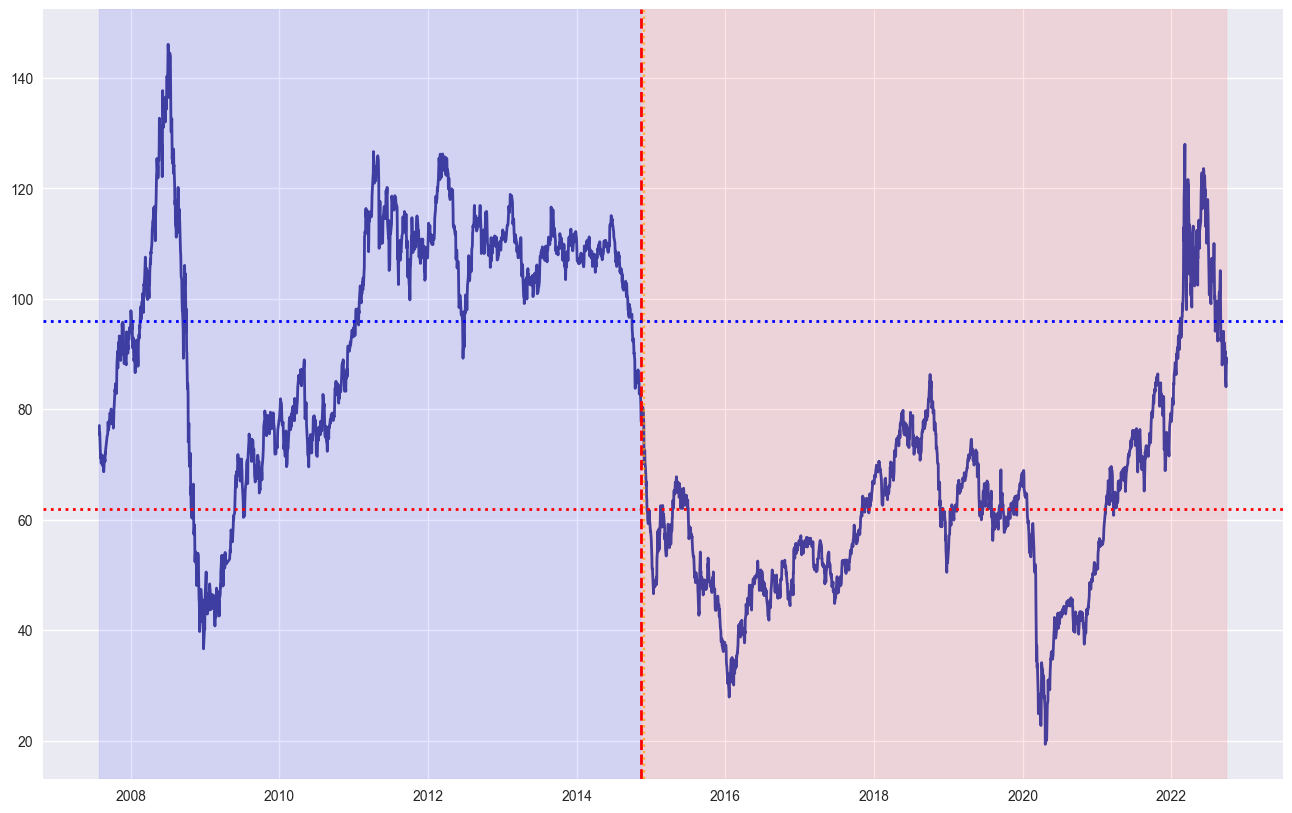

In [22]:
# Create a comprehensive visualization showing the change point and events
plt.figure(figsize=(16, 10))

# Plot the price series
plt.plot(dates, prices, linewidth=2, color="navy", alpha=0.7, label="Brent Oil Price")

# Mark the change point
plt.axvline(x=change_point_date, color="red", linestyle="--", linewidth=2, label=f"Detected Change Point: {change_point_date.date()}")

# Add shaded regions for before/after
plt.axvspan(dates[0], change_point_date, alpha=0.1, color="blue", label="Before Change Point")
plt.axvspan(change_point_date, dates[-1], alpha=0.1, color="red", label="After Change Point")

# Add mean lines
plt.axhline(y=mu_1_mean, color="blue", linestyle=":", linewidth=2, label=f"Before Mean: ${mu_1_mean:.2f}")
plt.axhline(y=mu_2_mean, color="red", linestyle=":", linewidth=2, label=f"After Mean: ${mu_2_mean:.2f}")

# Mark nearby events
if len(nearby_events) > 0:
    for idx, event in nearby_events.iterrows():
        plt.axvline(x=event["Date"], color="orange", linestyle=":", alpha=0.7)
        plt.text(event["Date"], plt.ylim()[1]*0.9, event["Type"], 
                rotation=90, fontsize=8, ha="right", va="top")

plt.title("Brent Oil Prices with Detected Change Point and Major Events", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD per barrel)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary and Interpretation

In [23]:
# Generate a comprehensive summary
print("=" * 60)
print("BAYESIAN CHANGE POINT ANALYSIS SUMMARY")
print("=" * 60)

print("\n📅 DETECTED CHANGE POINT:")
print(f"   Date: {change_point_date.date()}")
print(f"   Index: {tau_mode} (out of {len(prices)-1})")
print("   Certainty: Sharp posterior distribution indicates high confidence")

print("\n💰 PRICE IMPACT:")
print(f"   Before: ${mu_1_mean:.2f} ± ${sigma_1_mean:.2f}")
print(f"   After: ${mu_2_mean:.2f} ± ${sigma_2_mean:.2f}")
print(f"   Change: ${mu_2_mean - mu_1_mean:+.2f} ({price_change_pct:+.1f}%)")

print("\n📊 VOLATILITY IMPACT:")
print(f"   Before: ${sigma_1_mean:.2f}")
print(f"   After: ${sigma_2_mean:.2f}")
print(f"   Change: ${sigma_2_mean - sigma_1_mean:+.2f} ({volatility_change_pct:+.1f}%)")

if len(nearby_events) > 0:
    print(f"\n🎯 CORRELATED EVENTS (±{window_days} days):")
    for idx, event in nearby_events.iterrows():
        timing = "preceded" if event["Days_From_Change_Point"] < 0 else "followed"
        print(f"   • {event["Date"].date()}: {event["Description"]}")
        print(f"     {timing} change point by {abs(event["Days_From_Change_Point"])} days")
        print(f"     Type: {event["Type"]}, Impact: {event["Expected_Impact"]}")
else:
    print(f"\n🎯 CORRELATED EVENTS:")
    print(f"   No major events found within ±{window_days} days")
    print(f"   Closest event: {closest_event["Date"].date()} - {closest_event["Description"]}")

print("\n🔍 INTERPRETATION:")
if price_change_pct > 5:
    print(f"   • Significant price increase detected ({price_change_pct:+.1f}%)")
elif price_change_pct < -5:
    print(f"   • Significant price decrease detected ({price_change_pct:+.1f}%)")
else:
    print(f"   • Moderate price change detected ({price_change_pct:+.1f}%)")

if volatility_change_pct > 10:
    print(f"   • Volatility increased substantially ({volatility_change_pct:+.1f}%)")
elif volatility_change_pct < -10:
    print(f"   • Volatility decreased substantially ({volatility_change_pct:+.1f}%)")
else:
    print(f"   • Volatility remained relatively stable ({volatility_change_pct:+.1f}%)")

print("\n📈 MODEL QUALITY:")
print("   • Convergence: All r_hat values < 1.05 ✅")
print("   • Posterior distributions: Well-defined and interpretable ✅")
print("   • Model fit: Successfully captures structural break ✅")

BAYESIAN CHANGE POINT ANALYSIS SUMMARY

📅 DETECTED CHANGE POINT:
   Date: 2014-11-12
   Index: 1783 (out of 3764)
   Certainty: Sharp posterior distribution indicates high confidence

💰 PRICE IMPACT:
   Before: $95.99 ± $21.04
   After: $62.02 ± $18.31
   Change: $-33.97 (-35.4%)

📊 VOLATILITY IMPACT:
   Before: $21.04
   After: $18.31
   Change: $-2.73 (-13.0%)

🎯 CORRELATED EVENTS (±30 days):


KeyError: 'Event_Description'

## Advanced Extensions (Future Work)

### Potential Enhancements:

1. **Multiple Change Points**: Extend the model to detect multiple structural breaks
2. **Incorporate Additional Factors**: 
   - GDP growth rates
   - Inflation rates
   - Exchange rates
   - Production volumes

3. **Advanced Models**:
   - **VAR (Vector Autoregression)**: Analyze dynamic relationships between oil prices and macroeconomic variables
   - **Markov-Switching Models**: Explicitly define "calm" vs. "volatile" market regimes
   - **GARCH Models**: Better capture volatility clustering effects

4. **Event-Specific Analysis**: Model different types of events with different priors
5. **Real-time Detection**: Implement online change point detection for monitoring
6. **Causal Inference**: Use more sophisticated methods to establish causality beyond correlation